In [36]:
%load_ext autoreload
%autoreload 2  

import os
import ast

import numpy as np
import h5py
import sipyco.pyon as pyon
import glob
import pandas as pd
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
def binomial_prb_and_error(positives, total):
    z = 1
    nt = total + z ** 2
    pt = 1 / nt * (positives + z ** 2 / 2)
    unc = z / nt * (positives * (total - positives) / total + z**2 / 4) ** 0.5
    return pt, unc


def extract_collapsed_state_prob(file_name, scan_var, pmts, threshold=1, use_binomial=True, clean=False, return_counts=False):
    file = h5py.File(f"../../data/{file_name}.h5")
    data = file['datasets']['histogram_context']['histogram']['raw']
    num_points = len(data)
    num_shots = len(data["0"])
    state_data = np.zeros((num_points, 2**len(pmts)))
    state_err = np.zeros((num_points, 2**len(pmts)))

    all_keys = [format(i, f'0{len(pmts)}b')
                for i in range(2**len(pmts))]

    other_pmts: list[int] = []
    raw_counts = [{} for _ in range(num_points)]

    for i in range(num_points):
        point_data = np.array(data['{}'.format(i)])
        if clean and i == 0:
            other_pmts = [p for p in range(
                point_data.shape[1]) if p not in pmts]
        point_state = {}
        valid_shots = 0
        for j in range(len(point_data)):
            # first pmt is the least significant digit
            state_key = ''.join(
                [str(c) for c in [('1' if c > threshold else '0') for c in point_data[j]]])
            if clean and any(state_key[p] == '1' for p in other_pmts):
                # discard shots with excitations on pmts we don't care about
                continue
            valid_shots += 1
            collapsed_key = ''.join(state_key[p] for p in pmts)[::-1]
            point_state[collapsed_key] = point_state.get(collapsed_key, 0) + 1
        raw_counts[i] = {k: point_state.get(k, 0) for k in all_keys}
        for k in range(len(all_keys)):
            if valid_shots == 0:
                state_data[i][k] = 0
                state_err[i][k] = 0
            elif use_binomial:
                state_data[i][k], state_err[i][k] = binomial_prb_and_error(
                    positives=point_state.get(all_keys[k], 0), total=valid_shots)
            else:
                state_data[i][k] = point_state.get(
                    all_keys[k], 0) / valid_shots
                state_err[i][k] = 0

    x = np.array(file['datasets']['scan'][scan_var])
    df = pd.DataFrame({}, index=x[:num_points])

    if return_counts:
        for k in all_keys:
            df[k] = [raw_counts[i][k] for i in range(num_points)]
    else:
        for k in range(len(all_keys)):
            df[all_keys[k]] = state_data[:, k]
            df[f"{all_keys[k]}_err"] = state_err[:, k]

    df.sort_index(inplace=True)
    return df, valid_shots if clean else num_shots


In [38]:
# we turned on pmt -10 to 10 for all these experiments
PMT_CHANNELS = list(range(-10,10))
# for converting pmt channels to zero indexed indices (used in h5)
INDEX_OFFSET = 10
CIRCUIT_ROOT = "./SupermarqingSTAQ"
DATA_ROOT = "../../data"
DATA_PATH = f"{DATA_ROOT}/SuperMarq/20260423"

def ideal_probabilities(qasm_name: str) -> dict[str, float]:
    matches = glob.glob(f"{CIRCUIT_ROOT}/**/{qasm_name}.txt", recursive=True)
    if not matches:
        raise FileNotFoundError(f"No qasm file found for '{qasm_name}'")
    circuit = QuantumCircuit.from_qasm_file(matches[0])
    circuit.remove_final_measurements(inplace=True)
    sv = Statevector.from_instruction(circuit)
    return sv.probabilities_dict(), circuit.num_qubits

def find_file_name(qasm_name: str, preferred_index = 0) -> str:
    matches = glob.glob(f"{DATA_PATH}/**/*{qasm_name}*.h5", recursive=True)
    if not matches:
        raise FileNotFoundError(f"No file found for qasm_name='{qasm_name}'")
    index = 0
    if len(matches) > 1:
        index = preferred_index
        if preferred_index >= len(matches):
            index = 0
    # Return path relative to DATA_ROOT without extension (matches what extract_collapsed_state_prob expects)
    return os.path.splitext(os.path.relpath(matches[index], DATA_ROOT))[0]

def get_experiment_dist(qasm_name, num_qubits, clean=True, file_name=None):
    if file_name is None:
        file_name = find_file_name(qasm_name, preferred_index=1)
    file = h5py.File(f"{DATA_ROOT}/{file_name}.h5")
    arguments = file['expid'].asstr()[...].item()
    args = pyon.decode(arguments)
    qubit_to_channel_mapping = ast.literal_eval(args['arguments']['Qubit to channel mapping'])
    pmt_channels = [qubit_to_channel_mapping[i] for i in range(num_qubits)]
    pmt_indices = np.array(pmt_channels) + INDEX_OFFSET
    df, num_shots = extract_collapsed_state_prob(file_name=file_name, scan_var='dummy', pmts=pmt_indices, threshold=1, clean=clean)
    return df, num_shots, file_name

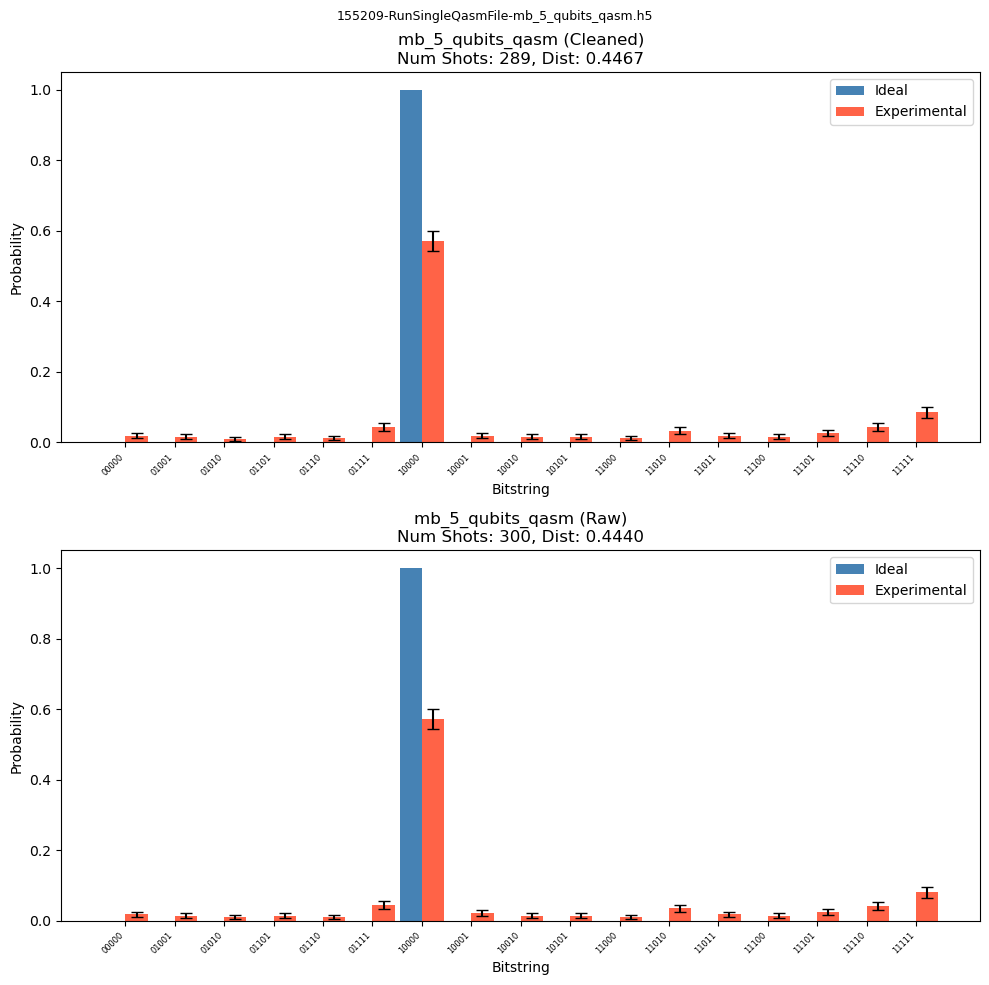

In [39]:
def plot_experiment(qasm_name, plot_threshold=0.01, file_name=None, save_path=None):
    probs, num_qubits = ideal_probabilities(qasm_name)
    df_clean, num_shots_clean, resolved_file_name = get_experiment_dist(qasm_name=qasm_name, num_qubits=num_qubits, clean=True, file_name=file_name)
    df_raw, num_shots_raw, _ = get_experiment_dist(qasm_name=qasm_name, num_qubits=num_qubits, clean=False, file_name=file_name)

    h5_file_name = os.path.basename(resolved_file_name) + ".h5"

    state_cols = [c for c in df_clean.columns if not c.endswith('_err')]
    err_cols = [f"{c}_err" for c in state_cols]

    ideal = np.array([probs.get(s, 0) for s in state_cols])
    exp_clean = df_clean[state_cols].iloc[0].values
    exp_err_clean = df_clean[err_cols].iloc[0].values
    exp_raw = df_raw[state_cols].iloc[0].values
    exp_err_raw = df_raw[err_cols].iloc[0].values

    mask = (ideal > plot_threshold) | (exp_clean > plot_threshold) | (exp_raw > plot_threshold)
    state_cols_f = [s for s, m in zip(state_cols, mask) if m]
    ideal_f = ideal[mask]
    exp_clean_f, exp_err_clean_f = exp_clean[mask], exp_err_clean[mask]
    exp_raw_f, exp_err_raw_f = exp_raw[mask], exp_err_raw[mask]

    dist_clean = np.sum(np.abs(exp_clean_f - ideal_f)**2)**(1/2)
    dist_raw = np.sum(np.abs(exp_raw_f - ideal_f)**2)**(1/2)

    x = np.arange(len(state_cols_f))
    width = 0.45

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    fig.suptitle(h5_file_name, fontsize=9)

    for ax, exp_v, exp_err_v, dist_v, num_shots_v, label in [
        (ax1, exp_clean_f, exp_err_clean_f, dist_clean, num_shots_clean, "Cleaned"),
        (ax2, exp_raw_f, exp_err_raw_f, dist_raw, num_shots_raw, "Raw"),
    ]:
        ax.bar(x - width / 2, ideal_f, width, label='Ideal', color='steelblue')
        ax.bar(x + width / 2, exp_v, width, yerr=exp_err_v, capsize=4, label='Experimental', color='tomato')
        ax.set_xlabel("Bitstring")
        ax.set_ylabel("Probability")
        ax.set_title(f"{qasm_name} ({label})\nNum Shots: {num_shots_v}, Dist: {dist_v:.4f}")
        ax.set_xticks(x)
        ax.set_xticklabels(state_cols_f, rotation=45, ha='right', fontsize=6)
        ax.legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

plot_experiment("mb_5_qubits_qasm")

In [40]:
qasm_names = [os.path.splitext(os.path.basename(f))[0] for f in glob.glob(f"{CIRCUIT_ROOT}/**/*.txt", recursive=True)]
print(f"Found {len(qasm_names)} qasm files: {qasm_names}")

for qasm_name in qasm_names:
    h5_files = glob.glob(f"{DATA_PATH}/**/*{qasm_name}*.h5", recursive=True)
    print(f"  {qasm_name}: {len(h5_files)} h5 files -> {h5_files}")

Found 143 qasm files: ['vqeproxy_7_qubits_4_layers_x_basis_qasm', 'vqeproxy_9_qubits_1_layers_z_basis_qasm', 'vqeproxy_4_qubits_4_layers_z_basis_qasm', 'vqeproxy_9_qubits_2_layers_x_basis_qasm', 'vqeproxy_7_qubits_3_layers_z_basis_qasm', 'vqeproxy_4_qubits_3_layers_x_basis_qasm', 'vqeproxy_4_qubits_3_layers_z_basis_qasm', 'vqeproxy_7_qubits_3_layers_x_basis_qasm', 'vqeproxy_9_qubits_2_layers_z_basis_qasm', 'vqeproxy_9_qubits_1_layers_x_basis_qasm', 'vqeproxy_4_qubits_4_layers_x_basis_qasm', 'vqeproxy_7_qubits_4_layers_z_basis_qasm', 'vqeproxy_4_qubits_2_layers_x_basis_qasm', 'vqeproxy_4_qubits_1_layers_z_basis_qasm', 'vqeproxy_9_qubits_4_layers_z_basis_qasm', 'vqeproxy_7_qubits_2_layers_z_basis_qasm', 'vqeproxy_7_qubits_1_layers_x_basis_qasm', 'vqeproxy_9_qubits_3_layers_x_basis_qasm', 'vqeproxy_9_qubits_3_layers_z_basis_qasm', 'vqeproxy_7_qubits_1_layers_z_basis_qasm', 'vqeproxy_7_qubits_2_layers_x_basis_qasm', 'vqeproxy_4_qubits_1_layers_x_basis_qasm', 'vqeproxy_9_qubits_4_layers_x_b

In [41]:
# for plotting and saving all h5 data
# qasm_names = [os.path.splitext(os.path.basename(f))[0] for f in glob.glob(f"{CIRCUIT_ROOT}/**/*.txt", recursive=True)]

# for qasm_name in qasm_names:
#     h5_files = glob.glob(f"{DATA_PATH}/**/*{qasm_name}*.h5", recursive=True)
#     for h5_path in h5_files:
#         file_name = os.path.splitext(os.path.relpath(h5_path, DATA_ROOT))[0]
#         save_path = os.path.splitext(h5_path)[0] + ".png"
#         try:
#             plot_experiment(qasm_name, file_name=file_name, save_path=save_path)
#             print(f"Saved: {save_path}")
#         except Exception as e:
#             print(f"Failed {h5_path}: {e}")